Index(['Incident ID', 'Date', 'Time', 'Category', 'Severity', 'Department',
       'Location', 'Description', 'Root Cause', 'Injuries', 'Lost Time Days',
       'Corrective Action', 'Status', 'Closed Date',
       'Severity (Numeric) 1=Near Miss … 5=Critical',
       'Category (Numeric) See legend', 'Department (Numeric) See legend',
       'Location (Numeric) See legend', 'Root Cause (Numeric) See legend',
       'Status (Numeric) See legend', 'Month (1–12)',
       'Day of Week 1=Mon … 7=Sun'],
      dtype='object')

MODEL TRAINED SUCCESSFULLY

Accuracy:
0.5

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.60      0.55         5
           2       0.67      0.67      0.67         9
           3       0.50      0.50      0.50         2
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         1

    accuracy                           0.50        20
   macro avg       0.33      

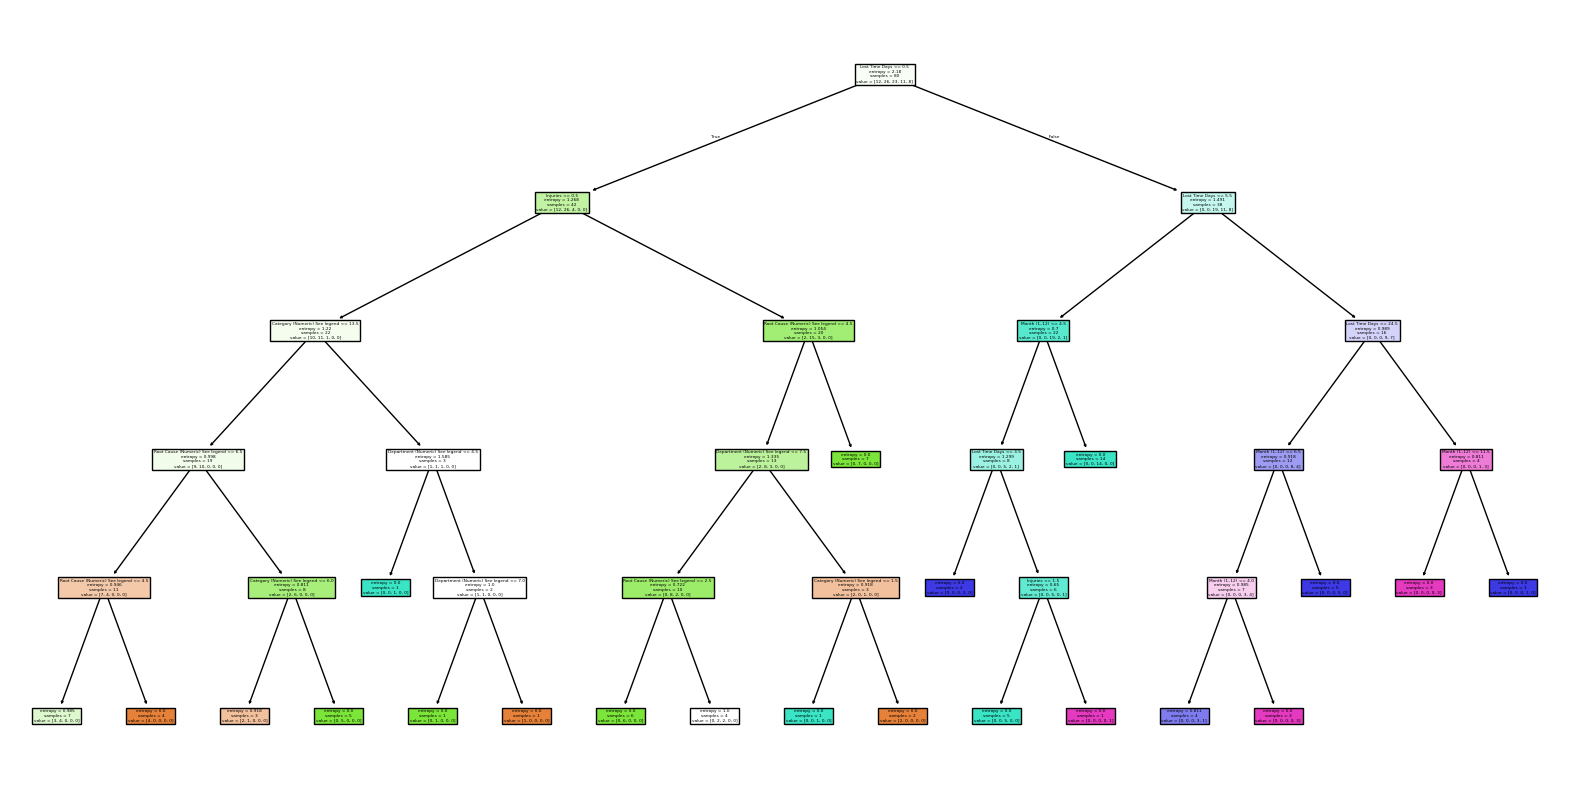


ENTER INCIDENT DETAILS


In [ ]:
# ----------------------------------
# DECISION TREE CLASSIFIER
# INDUSTRIAL INCIDENT DATASET
# ----------------------------------

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt


# -----------------------
# LOAD DATASET
# -----------------------

df = pd.read_excel("industrial_incident_reports (1).xlsx")

# Clean column names
df.columns = df.columns.str.replace('\n',' ')
df.columns = df.columns.str.strip()

print(df.columns)


# -----------------------
# INPUT FEATURES (X)
# -----------------------

X = df[[
    'Category (Numeric) See legend',
    'Department (Numeric) See legend',
    'Root Cause (Numeric) See legend',
    'Injuries',
    'Lost Time Days',
    'Month (1–12)'
]]


# -----------------------
# TARGET (Y)
# -----------------------

Y = df['Severity (Numeric) 1=Near Miss … 5=Critical']


# -----------------------
# TRAIN TEST SPLIT
# -----------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)


# -----------------------
# CREATE MODEL
# -----------------------

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)


# -----------------------
# TRAIN MODEL
# -----------------------

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY")


# -----------------------
# PREDICTIONS
# -----------------------

y_pred = model.predict(X_test)


# -----------------------
# EVALUATION
# -----------------------

print("\nAccuracy:")
print(accuracy_score(y_test,y_pred))

print("\nClassification Report:")
print(classification_report(y_test,y_pred))


# -----------------------
# TREE VISUALIZATION
# -----------------------

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.show()


# -----------------------
# USER INPUT
# -----------------------

print("\nENTER INCIDENT DETAILS")

category=float(input("Category Numeric: "))
department=float(input("Department Numeric: "))
rootcause=float(input("Root Cause Numeric: "))
injuries=float(input("Injuries: "))
lostdays=float(input("Lost Time Days: "))
month=float(input("Month: "))

sample=[[
    category,
    department,
    rootcause,
    injuries,
    lostdays,
    month
]]

prediction=model.predict(sample)

severity_names={
    1:"Near Miss",
    2:"Low",
    3:"Medium",
    4:"High",
    5:"Critical"
}

print("\nPredicted Severity:")
print(severity_names[prediction[0]])